# Visualization of CNNBiLSTMMLPRegressor Predictions

This notebook loads a pre-trained regression model and visualizes its predictions and attention weights on a random test sample.

In [1]:
import os
import sys
import torch
import random
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, Subset

# Add project root to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from models.model_regression import CNNBiLSTMMLPRegressor
from utils.train_utils.dataset import LPBSDataset

Using PyTorch features: ['X', 'Y', 'ComputedSpeed_frames']


In [ ]:
def get_dataset(data_dir, scaler_type, scaler_config_path, device):
    dataset = LPBSDataset(
        data_dir, 
        scaler_type=scaler_type, 
        mode="test", 
        scaler_config_path=scaler_config_path,
        device=device
    )
    print(f"Dataset size: {len(dataset)}")
    return dataset

def get_model(model_path, segment_len, embed_dim, device):
    model = CNNBiLSTMMLPRegressor(segment_len=segment_len, embed_dim=embed_dim).to(device)
    if os.path.exists(model_path):
        model.load_state_dict(torch.load(model_path, map_location=device))
        print("Model loaded successfully.")
    else:
        print(f"Warning: Model file not found at {model_path}. Using uninitialized model for demonstration.")
    model.eval()
    return model

def plot_data_histogram(dataset):
    x_values = []
    for i in range(len(dataset)):
        x, _, _ = dataset[i]
        x_values.append(x.cpu().numpy())
    x_values = np.concatenate(x_values, axis=0)
    plt.hist(x_values.flatten(), bins=200, edgecolor='black', log=True)
    plt.title("Histogram of dataset values")
    plt.show()

def run_inference(dataset, model, device, random_idx=None):
    if random_idx is None:
        random_idx = random.randint(0, len(dataset) - 1)
    data_tensor, label, total_segments = dataset[random_idx]
    data_tensor = data_tensor.cpu()
    T_actual = int(total_segments.item())
    
    print(f"Selected sample {random_idx} with {T_actual} valid segments.")
    
    predictions = []
    true_remaining = []
    true_objective = []
    
    with torch.no_grad():
        for t in range(1, T_actual + 1):
            x_t = data_tensor[:t].unsqueeze(0).to(device)
            mask = torch.ones(1, t).to(device)
            output, _, _ = model(x_t, mask=mask)
            
            knee_point = 150 // 3  # 50 segments

            predictions.append(output.item() * knee_point)
            true_remaining.append(float(T_actual - t))
            true_objective.append(min(float(T_actual - t), knee_point))

    with torch.no_grad():
        x_full = data_tensor[:T_actual].unsqueeze(0).to(device)
        mask_full = torch.ones(1, T_actual).to(device)
        _, s_weights_full, v_weights_full = model(x_full, mask=mask_full)
        
        s_weights_cpu = s_weights_full.squeeze().cpu().numpy()
        v_weights_cpu = v_weights_full.squeeze().cpu().numpy()
        
    return T_actual, true_objective, true_remaining, predictions, s_weights_cpu, v_weights_cpu, data_tensor

def plot_predictions(T_actual, true_objective, true_remaining, predictions, s_weights_cpu):
    steps = np.arange(1, T_actual + 1)
    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(steps, true_remaining, label="True Remaining Lifespan", linestyle="--", marker="o", markersize=4)
    plt.plot(steps, true_objective, label="True Objective (scaled)", linestyle=":", marker="s", markersize=4)
    plt.plot(steps, predictions, label="Predicted Remaining", marker="x", markersize=4)
    plt.xlabel("Segments observed (time)")
    plt.ylabel("Remaining segments")
    plt.title("Remaining Lifespan Prediction Over Time")
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.bar(steps, s_weights_cpu, color='skyblue', edgecolor='black')
    plt.xlabel("Segment index")
    plt.ylabel("Attention Weight")
    plt.title("Segment Attention Weights (at final step)")
    plt.grid(True, axis='y')
    
    plt.tight_layout()
    plt.show()

def plot_variances(v_weights_cpu):
    plt.figure(figsize=(10, 6))
    plt.imshow(v_weights_cpu.T, aspect='auto', cmap='viridis', origin='lower')
    plt.colorbar(label='Attention Weight')
    plt.xlabel("Segment index")
    plt.ylabel("Variate")
    plt.title("Variate Attention Weights Over Time (at final step)")
    plt.tight_layout()
    plt.show()

def analyze_gradients(model, data_tensor, T_actual, device):
    import torch.nn as nn
    model.zero_grad()
    model.train()
    
    x_full = data_tensor[:T_actual].unsqueeze(0).to(device)
    mask_full = torch.ones(1, T_actual).to(device)
    
    output, _, _ = model(x_full, mask=mask_full)
    target = torch.tensor([0.0], device=device)
    
    criterion = nn.SmoothL1Loss()
    loss = criterion(output, target)
    loss.backward()
    
    max_grads = {}
    for name, param in model.feature_extractor.named_parameters():
        if param.grad is not None:
            max_grads[name] = param.grad.abs().max().item()
            
    print("Max absolute gradients in CNN Feature Extractor parameters:")
    for name, max_g in max_grads.items():
        print(f"  {name}: {max_g:.6f}")
        
    plt.figure(figsize=(10, 4))
    plt.bar(list(max_grads.keys()), list(max_grads.values()), color='lightcoral', edgecolor='black')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Max Absolute Gradient')
    plt.title('Max Gradients in CNN Feature Extractor (Huber Loss)')
    plt.tight_layout()
    plt.show()

## 1. Configurations and Loading
Specify the paths to the dataset, the pre-trained model weights, and the required scaler configuration.

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Settings
data_dir = "../preprocessed_data/"
scaler_config_path = os.path.join(data_dir, "scaler_config.json")
model_path = "../ckpts/best_regressor_model.pth"  # Update with your actual model checkpoint path
scaler_type = "standard"

# Model hyperparameters (should match those used during training)
embed_dim = 64
segment_len = 900

Using device: cuda


## 2. Load Dataset
Initialize the `LPBSDataset` similar to `main_pipeline.py`.

In [4]:
dataset = get_dataset(data_dir, scaler_type, scaler_config_path, device)

Loading Data:  78%|███████▊  | 72/92 [00:11<00:03,  5.23it/s]c:\Users\elrbe\all_code\flep\ML\project-2-astiflop\utils\train_utils\dataset.py:520: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Loading Data: 100%|██████████| 92/92 [00:14<00:00,  6.20it/s]


Applied standard normalization.
Dataset size: 92


## 3. Load Model

In [5]:
model = get_model(model_path, segment_len, embed_dim, device)

Model loaded successfully.


## 4. Run Inference on a Random Sample
We pick a random sample, explicitly pass its sequence of segments format, and gather the incrementally predicted remaining lifespan along with the attention weights.

Selected sample 46 with 107 valid segments.


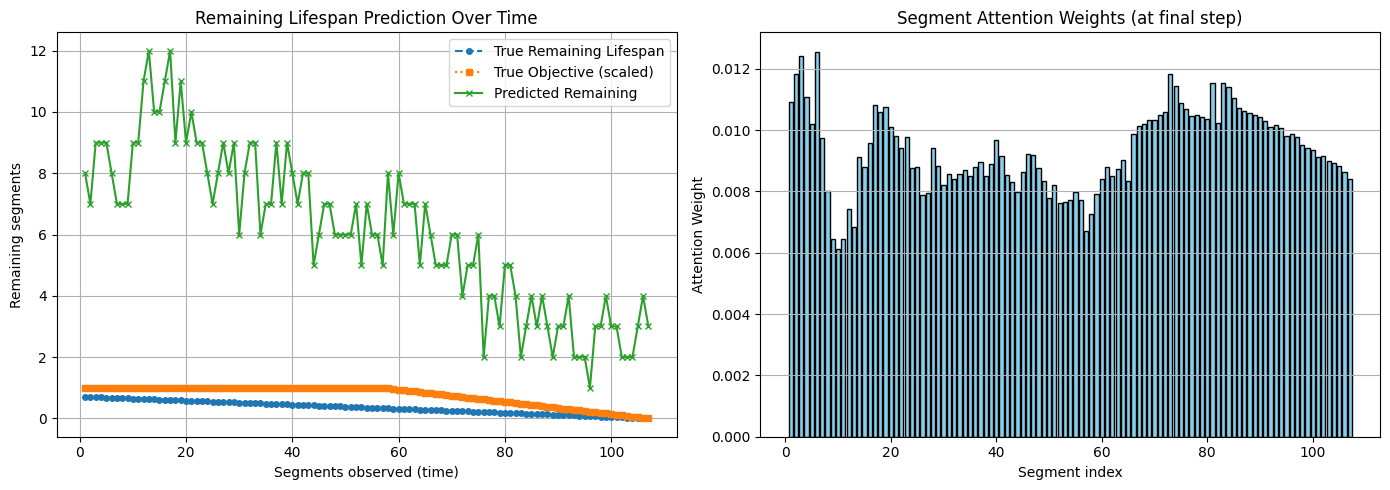

In [26]:
T_actual, true_objective, true_remaining, predictions, s_weights_cpu, v_weights_cpu, data_tensor = run_inference(dataset, model, device)
plot_predictions(T_actual, true_objective, true_remaining, predictions, s_weights_cpu)


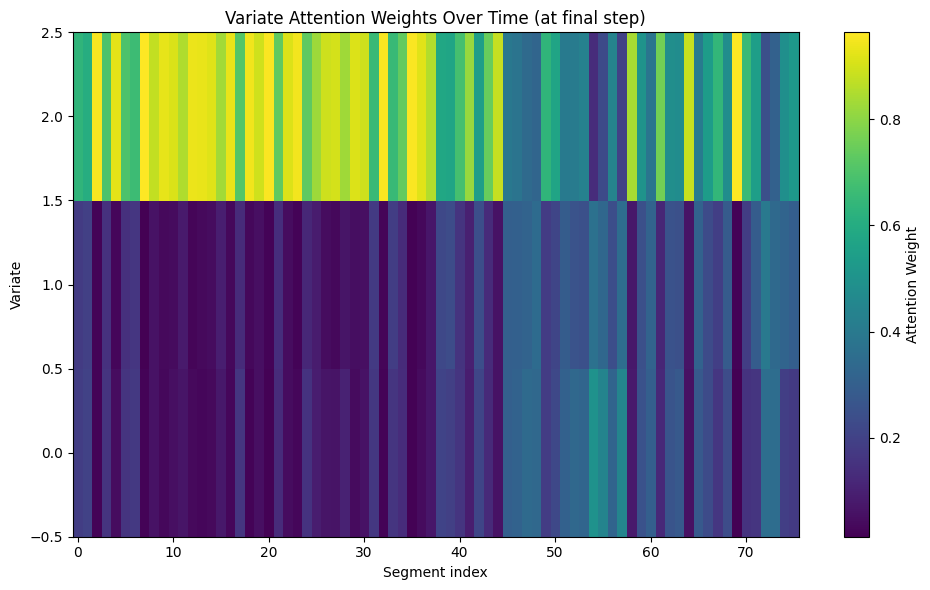

In [15]:
plot_variances(v_weights_cpu)

Max absolute gradients in CNN Feature Extractor parameters:
  conv1.weight: 0.001543
  conv1.bias: 0.001056
  conv2.weight: 0.001525
  conv2.bias: 0.001147
  conv3.weight: 0.002918
  conv3.bias: 0.002067
  fc.weight: 0.002167
  fc.bias: 0.002401


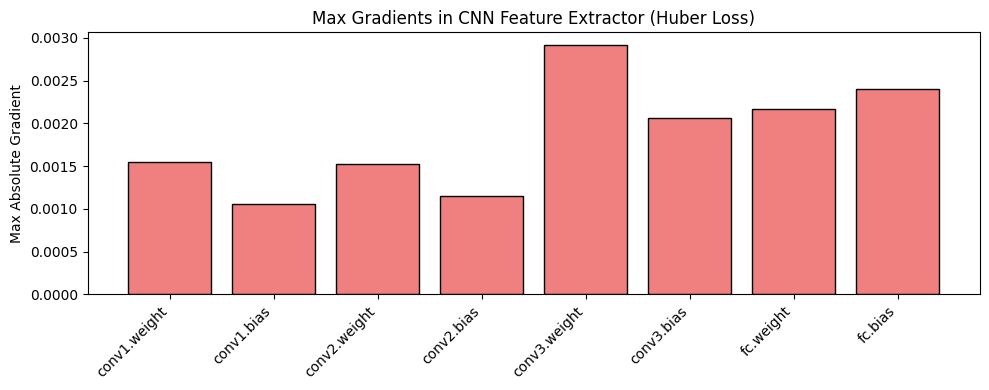

In [16]:
analyze_gradients(model, data_tensor, T_actual, device)